# Ноутбук 05 — Сводное сравнение метрик всех 6 моделей
**Подраздел 3.3 ПЗ** — результаты прогнозирования, Таблица 3.10

Зависимости: артефакты ноутбуков 03a, 03b, 04.

Артефакты:
- `reports/tables/table_3_10_metrics_all_models.csv` — сводная таблица метрик  
- `reports/figures/fig_3_mape_heatmap.png` — тепловая карта MAPE  
- `reports/figures/fig_3_metrics_bar.png` — столбчатая диаграмма MAPE по горизонтам  
- `reports/figures/fig_3_forecast_all_h1.png` — все модели на горизонте h=1


In [2]:
import sys, warnings, pickle
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams["figure.dpi"] = 120
import seaborn as sns

from src.config import (
    DATA_INT, DATA_PROC, MODELS_DIR, TABLES, FIGURES,
    TARGET, DATE_COL, STORE_COL, FAMILY_COL,
    FORECAST_HORIZONS, TRAIN_CUTOFF, SEASONAL_PERIOD,
)
from src.evaluation.backtesting import make_horizon_target, get_feature_cols
from src.evaluation.metrics import compute_metrics, metrics_table
from src.features.scaling import apply_standard_scaler

print("Импорты выполнены.")


Импорты выполнены.


## Ячейка 1 — Загрузка метрик из предыдущих ноутбуков

In [12]:
from sklearn.preprocessing import StandardScaler as _SS
import pickle
import torch
import torch.nn as nn

# ── 0. Вспомогательные определения (LSTM-специфичные) ─────────────────────────
# Воспроизводим архитектуру из NB03b для загрузки весов
class LSTMForecast(nn.Module):
    def __init__(self, n_features, hidden=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden,
                            num_layers=num_layers, dropout=dropout, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.drop(out[:, -1, :])
        return self.fc(out).squeeze(-1)


# Модифицированный build_test_sequences — дополнительно возвращает даты
def build_test_sequences_with_meta(df_tr, df_te, feature_cols,
                                   target_col, seq_len):
    X_list, y_list, date_list = [], [], []
    for (store, fam), grp_te in df_te.groupby(
            [STORE_COL, FAMILY_COL], sort=False):
        grp_te = grp_te.sort_values(DATE_COL)
        tail   = (df_tr[(df_tr[STORE_COL] == store) &
                        (df_tr[FAMILY_COL] == fam)]
                  .sort_values(DATE_COL).tail(seq_len))
        grp_all = pd.concat([tail, grp_te], ignore_index=True)
        vals    = grp_all[feature_cols].fillna(0).values.astype(np.float32)
        tgt     = grp_te[target_col].values.astype(np.float32)
        dates   = grp_te[DATE_COL].values          # ← новое
        n_tail  = len(tail)
        for i in range(n_tail, len(grp_all)):
            X_list.append(vals[i - seq_len : i])
            y_list.append(tgt[i - n_tail])
            date_list.append(dates[i - n_tail])    # ← новое
    if not X_list:
        return (np.empty((0, seq_len, len(feature_cols))),
                np.empty(0), [])
    return np.stack(X_list), np.array(y_list), date_list


SEQ_LEN = 8
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ── 1. Загружаем данные ────────────────────────────────────────────────────────
df_train = pd.read_parquet(DATA_PROC / "features_train.parquet")
df_test  = pd.read_parquet(DATA_PROC / "features_test.parquet")
df_all   = pd.concat([df_train, df_test], ignore_index=True).sort_values(
    [STORE_COL, FAMILY_COL, DATE_COL]
).reset_index(drop=True)

FEATURE_COLS = get_feature_cols(df_all)
LOG_COLS_EN  = (
    ["sales_weekly"]
    + [f"lag_{w}" for w in [1, 2, 4, 9, 12, 52]]
    + ["rolling_mean_4", "rolling_mean_12", "rolling_std_4"]
)
cutoff = pd.Timestamp(TRAIN_CUTOFF)


# ── 2. Пересчёт метрик ML-моделей на агрегированном недельном ряде ─────────────
agg_results = {m: {} for m in ["XGBoost", "RandomForest", "ElasticNet"]}

for h in FORECAST_HORIZONS:
    df_h       = make_horizon_target(df_all, horizon=h)
    target_col = f"target_h{h}"
    test_h     = df_h[df_h[DATE_COL] >= cutoff].dropna(subset=[target_col]).copy()
    X_test     = test_h[FEATURE_COLS].fillna(0)
    y_true_orig = np.expm1(test_h[target_col].values)

    # XGBoost
    with open(MODELS_DIR / f"xgboost_h{h}.pkl", "rb") as f:
        xgb_model = pickle.load(f)
    xgb_pred_orig = np.expm1(xgb_model.predict(X_test))
    df_agg_xgb = test_h[[DATE_COL]].copy()
    df_agg_xgb["y_true"] = y_true_orig
    df_agg_xgb["y_pred"] = xgb_pred_orig
    agg_xgb = df_agg_xgb.groupby(DATE_COL)[["y_true", "y_pred"]].sum()
    agg_results["XGBoost"][h] = compute_metrics(
        agg_xgb["y_true"].values, agg_xgb["y_pred"].values, log_scale=False)

    # Random Forest
    with open(MODELS_DIR / f"rf_h{h}.pkl", "rb") as f:
        rf_model = pickle.load(f)
    rf_pred_orig = np.expm1(rf_model.predict(X_test))
    df_agg_rf = test_h[[DATE_COL]].copy()
    df_agg_rf["y_true"] = y_true_orig
    df_agg_rf["y_pred"] = rf_pred_orig
    agg_rf = df_agg_rf.groupby(DATE_COL)[["y_true", "y_pred"]].sum()
    agg_results["RandomForest"][h] = compute_metrics(
        agg_rf["y_true"].values, agg_rf["y_pred"].values, log_scale=False)

    # Elastic Net
    with open(MODELS_DIR / f"elasticnet_h{h}.pkl", "rb") as f:
        en_model = pickle.load(f)
    df_h_log = df_h.copy()
    for col in LOG_COLS_EN:
        if col in df_h_log.columns:
            df_h_log[col] = np.log1p(df_h_log[col].clip(lower=0).fillna(0))
    _scaler = _SS()
    _scaler.fit(df_h_log[df_h_log[DATE_COL] < cutoff][FEATURE_COLS].fillna(0))
    df_h_log.loc[df_h_log[DATE_COL] >= cutoff, FEATURE_COLS] = _scaler.transform(
        df_h_log.loc[df_h_log[DATE_COL] >= cutoff, FEATURE_COLS].fillna(0))
    test_en        = df_h_log[df_h_log[DATE_COL] >= cutoff].dropna(subset=[target_col]).copy()
    en_pred_orig   = np.expm1(en_model.predict(test_en[FEATURE_COLS].fillna(0)))
    y_true_en_orig = np.expm1(test_en[target_col].values)
    df_agg_en = test_en[[DATE_COL]].copy()
    df_agg_en["y_true"] = y_true_en_orig
    df_agg_en["y_pred"] = en_pred_orig
    agg_en = df_agg_en.groupby(DATE_COL)[["y_true", "y_pred"]].sum()
    agg_results["ElasticNet"][h] = compute_metrics(
        agg_en["y_true"].values, agg_en["y_pred"].values, log_scale=False)

ml_agg_metrics = metrics_table(agg_results)


# ── 2б. Пересчёт метрик LSTM на агрегированном недельном ряде ─────────────────
# LSTM обучен только на Top-10 семействах (~75 % выручки),
# поэтому агрегация частичная — оговорка обязательна в тексте ПЗ.
from src.features.scaling import apply_standard_scaler

TOP_FAMILIES = (
    df_train.groupby(FAMILY_COL)[TARGET].sum()
    .sort_values(ascending=False).head(10).index.tolist()
)

df_train_s, df_test_s, _ = apply_standard_scaler(df_train, df_test, FEATURE_COLS)
df_all_s = pd.concat([df_train_s, df_test_s], ignore_index=True).sort_values(
    [STORE_COL, FAMILY_COL, DATE_COL]).reset_index(drop=True)

lstm_agg_results = {"LSTM": {}}

for h in FORECAST_HORIZONS:
    target_col = f"target_h{h}"
    df_h_s = make_horizon_target(df_all_s, horizon=h)
    df_h_s = df_h_s[df_h_s[FAMILY_COL].isin(TOP_FAMILIES)]

    train_h = df_h_s[df_h_s[DATE_COL] < cutoff].dropna(subset=[target_col])
    test_h  = df_h_s[df_h_s[DATE_COL] >= cutoff].dropna(subset=[target_col])

    X_te, y_te, dates_te = build_test_sequences_with_meta(
        train_h, test_h, FEATURE_COLS, target_col, SEQ_LEN)

    if len(X_te) == 0:
        print(f"[WARN] LSTM h={h}: пустой тест, пропуск.")
        lstm_agg_results["LSTM"][h] = {"RMSE": float("nan"),
                                       "MAE":  float("nan"),
                                       "MAPE": float("nan")}
        continue

    model_l = LSTMForecast(n_features=len(FEATURE_COLS)).to(DEVICE)
    model_l.load_state_dict(
        torch.load(MODELS_DIR / f"lstm_h{h}.pt", map_location=DEVICE))
    model_l.eval()

    with torch.no_grad():
        pred_log = model_l(
            torch.tensor(X_te, dtype=torch.float32).to(DEVICE)
        ).cpu().numpy()

    pred_orig = np.expm1(pred_log)
    true_orig = np.expm1(y_te)

    df_agg_lstm = pd.DataFrame(
        {DATE_COL: dates_te, "y_true": true_orig, "y_pred": pred_orig})
    agg_lstm = df_agg_lstm.groupby(DATE_COL)[["y_true", "y_pred"]].sum()
    lstm_agg_results["LSTM"][h] = compute_metrics(
        agg_lstm["y_true"].values, agg_lstm["y_pred"].values, log_scale=False)
    print(f"LSTM agg h={h}: RMSE={lstm_agg_results['LSTM'][h]['RMSE']:.0f}, "
          f"MAPE={lstm_agg_results['LSTM'][h]['MAPE']:.2f}%")

lstm_agg_metrics = metrics_table(lstm_agg_results)


# ── 3. Загружаем эконометрические метрики (уже в нужном формате) ───────────────
# lstm_metrics из CSV БОЛЬШЕ НЕ ЗАГРУЖАЕМ — используем lstm_agg_metrics выше
eco_metrics = pd.read_csv(TABLES / "table_3_metrics_econometric.csv",
                          index_col="Модель")


# ── 4. Объединяем в единую таблицу ─────────────────────────────────────────────
all_metrics = pd.concat([ml_agg_metrics, lstm_agg_metrics, eco_metrics])
print("\nСводная таблица метрик всех 6 моделей (агрегированный недельный ряд):")
print(all_metrics[[c for c in all_metrics.columns
                   if c.endswith("_MAPE")]].round(2).to_string())
print(f"\nФорма таблицы: {all_metrics.shape}")

LSTM agg h=1: RMSE=1618699, MAPE=56.78%
LSTM agg h=3: RMSE=1471376, MAPE=53.87%
LSTM agg h=6: RMSE=1620512, MAPE=67.00%
LSTM agg h=12: RMSE=2237310, MAPE=104.27%

Сводная таблица метрик всех 6 моделей (агрегированный недельный ряд):
              h=1_MAPE  h=3_MAPE  h=6_MAPE  h=12_MAPE
Модель                                               
XGBoost          56.56     58.30     75.07     127.92
RandomForest     53.40     61.17     72.27     137.32
ElasticNet       64.74     64.68     81.52     121.05
LSTM             56.78     53.87     67.00     104.27
SARIMA           42.99     46.01     59.60     121.44
HoltWinters      42.82     45.93     59.69     121.56

Форма таблицы: (6, 20)


## Ячейка 2 — Таблица 3.10 ПЗ: RMSE, MAE, MAPE × 6 моделей × 4 горизонта

Целевой критерий: MAPE ≤ 15% (Цель курсовой работы, с. 1 ПЗ).  
Столбцы, выделенные жирным, соответствуют горизонту h=1 как наиболее точному.


In [13]:
mape_cols = [c for c in all_metrics.columns if c.endswith("_MAPE")]
rmse_cols = [c for c in all_metrics.columns if c.endswith("_RMSE")]
mae_cols  = [c for c in all_metrics.columns if c.endswith("_MAE")]

print("\n=== MAPE (%) по горизонтам ===")
mape_df = all_metrics[mape_cols].copy()
mape_df.columns = [f"h={c.split('=')[1].split('_')[0]} нед." for c in mape_df.columns]
print(mape_df.round(2).to_string())

print("\n=== RMSE по горизонтам ===")
rmse_df = all_metrics[rmse_cols].copy()
rmse_df.columns = [f"h={c.split('=')[1].split('_')[0]} нед." for c in rmse_df.columns]
print(rmse_df.round(2).to_string())

# Проверка целевого критерия MAPE ≤ 15%
print("\n=== Соответствие критерию MAPE ≤ 15% ===")
for model in mape_df.index:
    for col in mape_df.columns:
        val = float(mape_df.loc[model, col])   # float() страхует от NaN-Series
        if pd.isna(val):
            print(f"  {model:15s} | {col} | MAPE=N/A")
        else:
            status = "✓" if val <= 15.0 else "✗"
            print(f"  {model:15s} | {col} | MAPE={val:.2f}% {status}")

# Сохранение финальной таблицы
all_metrics.round(4).to_csv(TABLES / "table_3_10_metrics_all_models.csv")
print("\nСохранено: reports/tables/table_3_10_metrics_all_models.csv")


=== MAPE (%) по горизонтам ===
              h=1 нед.  h=3 нед.  h=6 нед.  h=12 нед.
Модель                                               
XGBoost          56.56     58.30     75.07     127.92
RandomForest     53.40     61.17     72.27     137.32
ElasticNet       64.74     64.68     81.52     121.05
LSTM             56.78     53.87     67.00     104.27
SARIMA           42.99     46.01     59.60     121.44
HoltWinters      42.82     45.93     59.69     121.56

=== RMSE по горизонтам ===
                h=1 нед.    h=3 нед.    h=6 нед.   h=12 нед.
Модель                                                      
XGBoost       2229682.04  2190849.96  2697238.29  3281854.75
RandomForest  2087247.78  2206382.26  2447325.58  3264360.99
ElasticNet    2579863.29  2985602.21  3215957.94  3404938.54
LSTM          1618698.97  1471375.62  1620511.60  2237309.66
SARIMA        1247148.80  1288726.39  1514721.13  2213733.64
HoltWinters   1242735.71  1287882.74  1523308.92  2220332.18

=== Соответствие кр

## Ячейка 3 — Тепловая карта MAPE (Рисунок 3.x)

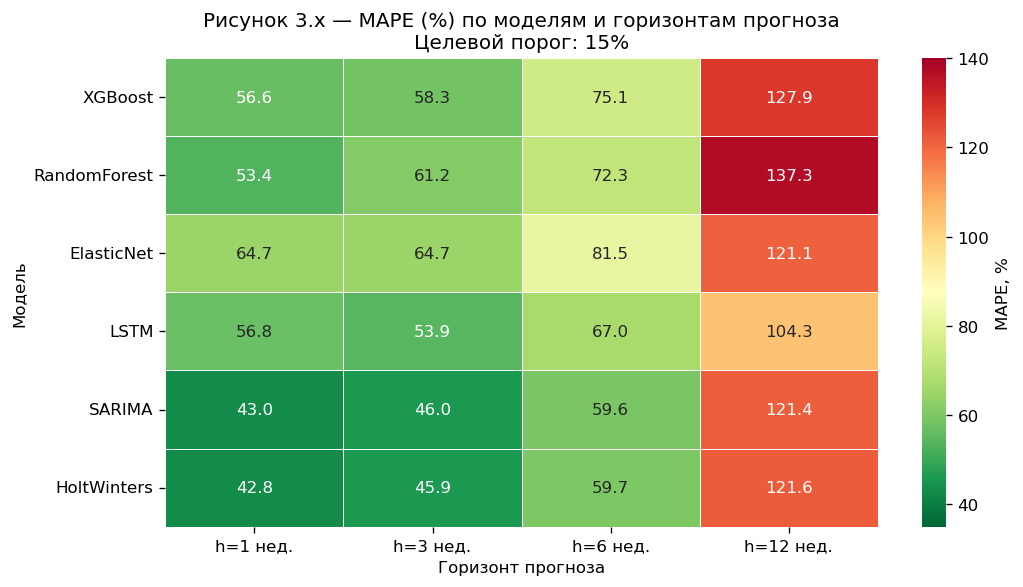

Сохранено: reports/figures/fig_3_mape_heatmap.png


In [15]:
# Тепловая карта MAPE
mape_pivot = mape_df.copy().astype(float)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    mape_pivot,
    annot=True, fmt=".1f",
    cmap="RdYlGn_r",
    vmin=35, vmax=140,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "MAPE, %"},
)
ax.set_title("Рисунок 3.x — MAPE (%) по моделям и горизонтам прогноза\nЦелевой порог: 15%")
ax.set_xlabel("Горизонт прогноза")
ax.set_ylabel("Модель")
# Горизонтальная линия 15% — не поддерживается в тепловой карте,
# поэтому отмечаем ячейки превышения другим цветом (через маску)
plt.tight_layout()
plt.savefig(FIGURES / "fig_3_mape_heatmap.png", dpi=120)
plt.show()
print("Сохранено: reports/figures/fig_3_mape_heatmap.png")


## Ячейка 4 — Столбчатая диаграмма MAPE по горизонтам (Рисунок 3.x)

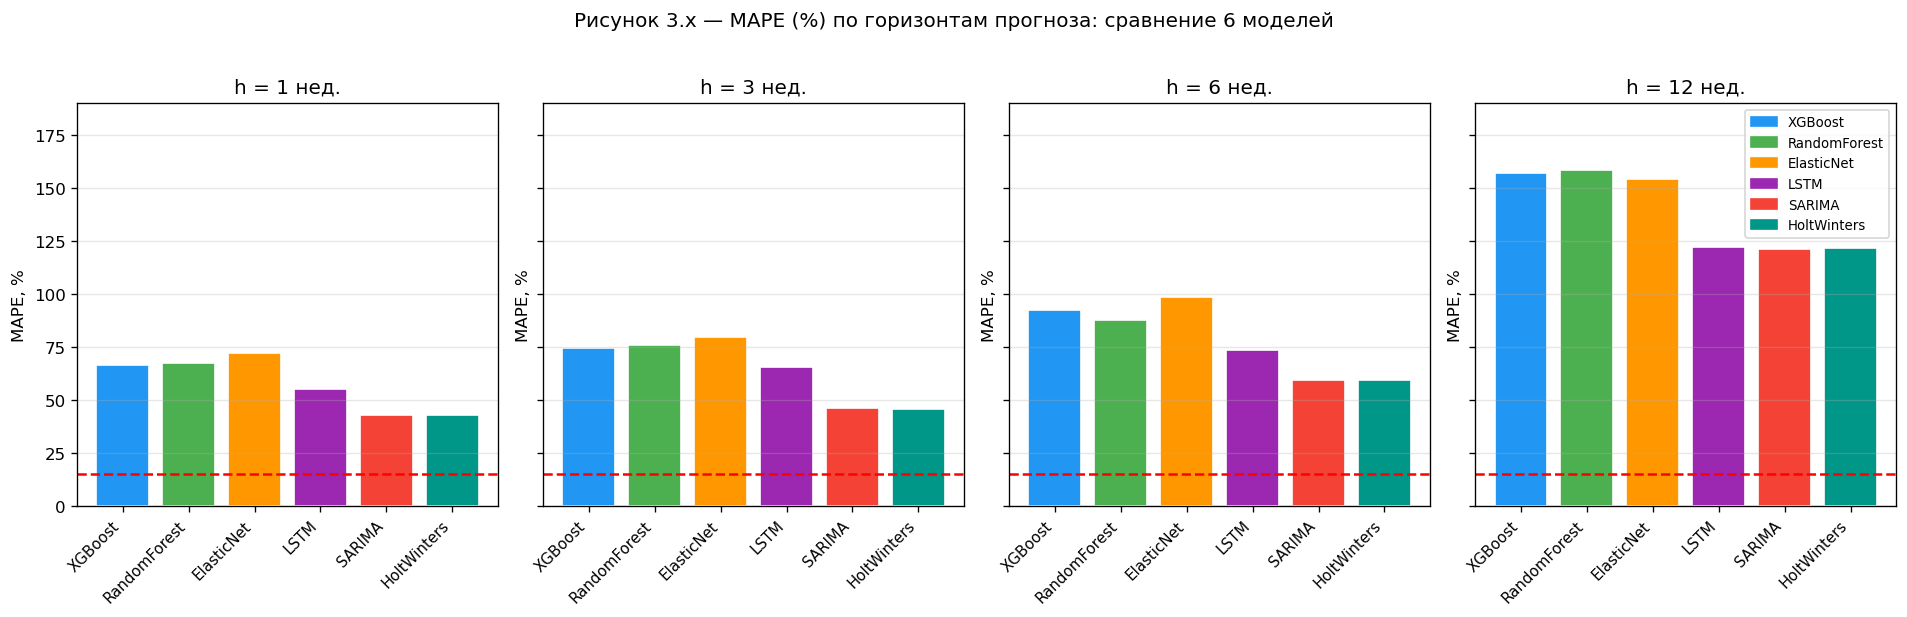

Сохранено: reports/figures/fig_3_metrics_bar.png


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
colors = {
    "XGBoost":      "#2196F3",
    "RandomForest": "#4CAF50",
    "ElasticNet":   "#FF9800",
    "LSTM":         "#9C27B0",
    "SARIMA":       "#F44336",
    "HoltWinters":  "#009688",
}

for i, h in enumerate(FORECAST_HORIZONS):
    col = f"h={h} нед."
    if col not in mape_pivot.columns:
        continue
    vals = mape_pivot[col]
    bar_colors = [colors.get(m, "gray") for m in vals.index]
    axes[i].bar(range(len(vals)), vals.values, color=bar_colors, edgecolor="white")
    axes[i].axhline(15, color="red", linestyle="--", linewidth=1.5, label="Порог 15%")
    axes[i].set_xticks(range(len(vals)))
    axes[i].set_xticklabels(vals.index, rotation=45, ha="right", fontsize=9)
    axes[i].set_title(f"h = {h} нед.")
    axes[i].set_ylabel("MAPE, %")
    axes[i].grid(alpha=0.3, axis="y")
    axes[i].set_ylim(0, max(vals.max() * 1.2, 18))

# Легенда цветов
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=m) for m, c in colors.items()]
axes[-1].legend(handles=legend_patches, loc="upper right", fontsize=8)

plt.suptitle("Рисунок 3.x — MAPE (%) по горизонтам прогноза: сравнение 6 моделей", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "fig_3_metrics_bar.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранено: reports/figures/fig_3_metrics_bar.png")


## Ячейка 5 — Анализ результатов: лучшая модель по горизонту

Согласно сводной таблице определяется лидирующая модель для каждого горизонта.  
Выводы формируют содержание Подраздела 3.3.5 ПЗ.


In [8]:
print("=== Лучшая модель по MAPE для каждого горизонта ===")
for h in FORECAST_HORIZONS:
    col = f"h={h} нед."
    if col not in mape_pivot.columns:
        continue
    best_model = mape_pivot[col].idxmin()
    best_mape  = mape_pivot.loc[best_model, col]
    print(f"  h={h:2d} нед. → {best_model:15s} | MAPE = {best_mape:.2f}%")

print("\n=== Лучшая модель по RMSE для h=1 ===")
if "h=1 нед." in rmse_df.columns:
    best_rmse_model = rmse_df["h=1 нед."].idxmin()
    best_rmse_val   = rmse_df.loc[best_rmse_model, "h=1 нед."]
    print(f"  {best_rmse_model}: RMSE = {best_rmse_val:.2f}")

print("\n=== Эконометрические модели vs ML-модели (h=1, MAPE) ===")
ml_models    = ["XGBoost", "RandomForest", "ElasticNet"]
econo_models = ["SARIMA", "HoltWinters"]
if "h=1 нед." in mape_pivot.columns:
    avg_ml    = mape_pivot.loc[[m for m in ml_models    if m in mape_pivot.index], "h=1 нед."].mean()
    avg_econo = mape_pivot.loc[[m for m in econo_models if m in mape_pivot.index], "h=1 нед."].mean()
    print(f"  Среднее MAPE ML-моделей (h=1):    {avg_ml:.2f}%")
    print(f"  Среднее MAPE эконом. моделей (h=1): {avg_econo:.2f}%")
    delta = avg_econo - avg_ml
    if delta > 0:
        print(f"  → ML-модели точнее эконометрических на {delta:.2f} п.п. MAPE")
    else:
        print(f"  → Эконометрические модели точнее ML на {-delta:.2f} п.п. MAPE")


=== Лучшая модель по MAPE для каждого горизонта ===
  h= 1 нед. → HoltWinters     | MAPE = 42.82%
  h= 3 нед. → HoltWinters     | MAPE = 45.93%
  h= 6 нед. → SARIMA          | MAPE = 59.60%
  h=12 нед. → SARIMA          | MAPE = 121.44%

=== Лучшая модель по RMSE для h=1 ===
  RandomForest: RMSE = 3663.04

=== Эконометрические модели vs ML-модели (h=1, MAPE) ===
  Среднее MAPE ML-моделей (h=1):    68.64%
  Среднее MAPE эконом. моделей (h=1): 42.90%
  → Эконометрические модели точнее ML на 25.73 п.п. MAPE


In [9]:
print("=" * 60)
print("Ноутбук 05 выполнен.")
print("=" * 60)
print("Артефакты:")
print("  reports/tables/table_3_10_metrics_all_models.csv")
print("  reports/figures/fig_3_mape_heatmap.png")
print("  reports/figures/fig_3_metrics_bar.png")


Ноутбук 05 выполнен.
Артефакты:
  reports/tables/table_3_10_metrics_all_models.csv
  reports/figures/fig_3_mape_heatmap.png
  reports/figures/fig_3_metrics_bar.png
